In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")

print("Path to dataset files:", path)

100%|██████████| 11.1M/11.1M [00:00<00:00, 13.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/versions/1


In [2]:
!pip install kagglehub pandas numpy matplotlib seaborn nltk scikit-learn wordcloud


In [3]:
#  Download and Load the Dataset
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline



# Download Dataset
path=kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")

print("Dataset path:",path)

print(os.listdir(path))

Using Colab cache for faster access to the 'sentiment-analysis-for-mental-health' dataset.
Dataset path: /kaggle/input/sentiment-analysis-for-mental-health
['Combined Data.csv']


In [4]:
file_path=os.path.join(path,"Combined Data.csv")
df=pd.read_csv(file_path)

df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [5]:
print(df.shape)

(53043, 3)


In [6]:
print(df.columns)

Index(['Unnamed: 0', 'statement', 'status'], dtype='object')


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB
None


In [8]:
print(df.isnull().sum())

Unnamed: 0      0
statement     362
status          0
dtype: int64


In [9]:
print(df.duplicated().sum())

0


In [10]:
# Class distribution
print(df['status'].value_counts())

status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


In [11]:
# Remove Missing Values
df.dropna(inplace=True)
print(df.isnull().sum())

Unnamed: 0    0
statement     0
status        0
dtype: int64


In [13]:
# Rename Columns
df.rename(columns={'statement':'text',
          'satus':'label'},inplace=True)
df.head()

,Unnamed: 0,text,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [15]:
df.rename(columns={'Unnamed: 0': 'unnamed'}, inplace=True)
df.head()

,unnamed,text,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


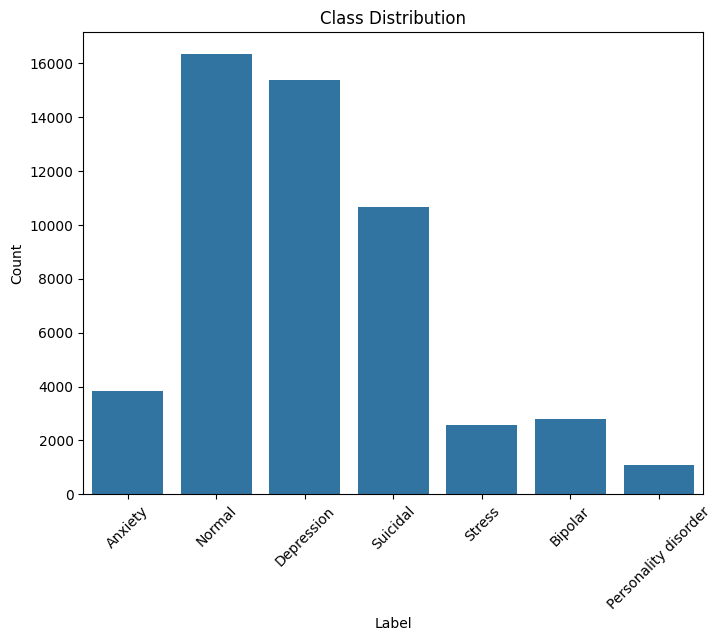

In [17]:
# check class imbalance

plt.figure(figsize=(8,6))
sns.countplot(x=df['status'],data=df)
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.title('Class Distribution')
plt.show()

In [19]:
import re
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [20]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation/special chars
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [21]:
df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head()

,text,clean_text
0,oh my gosh,oh gosh
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",wrong back dear forward doubt stay restless re...
3,I've shifted my focus to something else but I'...,ive shifted focus something else im still worried
4,"I'm restless and restless, it's been a month n...",im restless restless month boy mean


In [22]:
# Remove Empty Text Rows

df = df[df['clean_text'].str.strip() != '']

print(df.shape)

(52546, 4)


In [24]:
# Encode label

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['label_encoded'] = encoder.fit_transform(df['status'])

print(dict(zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
)))

{'Anxiety': np.int64(0), 'Bipolar': np.int64(1), 'Depression': np.int64(2), 'Normal': np.int64(3), 'Personality disorder': np.int64(4), 'Stress': np.int64(5), 'Suicidal': np.int64(6)}


In [25]:
# Split Data
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
#  Convert Text to Numerical Features (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [27]:
# Training linear SVM
from sklearn.svm import LinearSVC

model = LinearSVC()

model.fit(X_train_tfidf, y_train)

LinearSVC()

In [28]:
y_pred = model.predict(X_test_tfidf)

In [29]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7504281636536632

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.73      0.76       768
           1       0.80      0.76      0.78       556
           2       0.70      0.71      0.70      3081
           3       0.84      0.94      0.89      3243
           4       0.78      0.59      0.67       215
           5       0.60      0.46      0.52       517
           6       0.66      0.61      0.64      2130

    accuracy                           0.75     10510
   macro avg       0.74      0.68      0.71     10510
weighted avg       0.74      0.75      0.75     10510



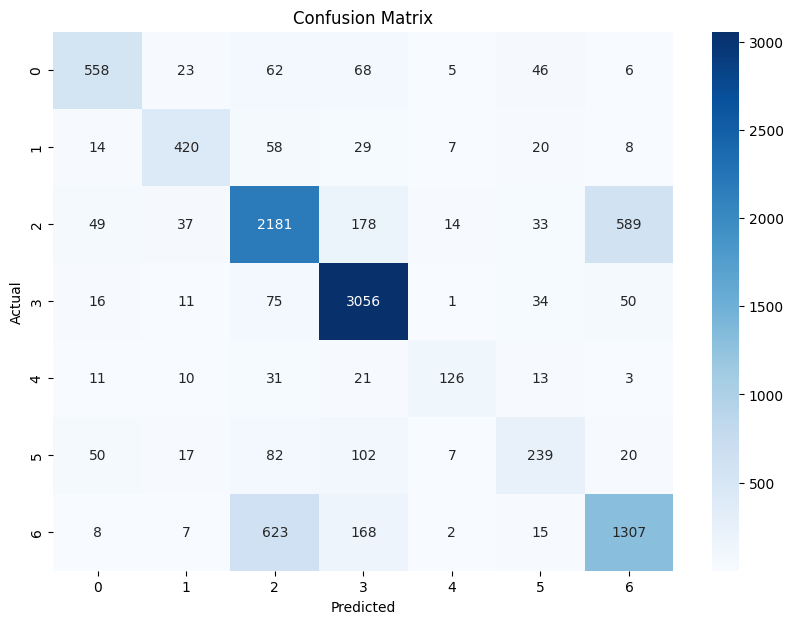

In [30]:
plt.figure(figsize=(10,7))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
# Handle Imbalanced Data
model = LinearSVC(class_weight='balanced')

In [36]:
# Try another model (logistic Regression)

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000)

In [37]:
# save the model
import joblib

joblib.dump(model, "mental_health_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [39]:
# Test on New Text
sample = ["I feel hopeless and exhausted"]

sample_clean = [clean_text(text) for text in sample]

sample_vector = vectorizer.transform(sample_clean)

prediction = lr.predict(sample_vector) # Changed 'model' to 'lr'

print(
    "Predicted Label:",
    encoder.inverse_transform(prediction)
)

Predicted Label: ['Depression']
